# Presentación de los datos
Para la realización de la Tarea voy a utilizar unos datos descargados de INE que contiene los datos de viajeros en transporte urbano por autobús desglosados por CCAA

https://www.ine.es/jaxiT3/Tabla.htm?t=20240



In [4]:
# Importamos las bibliotecas necesarias
import os
import pandas as pd
import numpy as np    
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm
from itertools import product
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [6]:
import warnings
# Establecer el nivel de advertencias a "ignore" para ignorar todas las advertencias
warnings.filterwarnings("ignore")

In [8]:
#******************* 1. Introducción y lectura de datos
# Definimos nuestro entorno de trabajo.
os.chdir(r'C:\Users\MAICKEL\OneDrive\Documents\MASTER_UCM\MODULO 7 -P3- MINERIA DE DATOS (descomposición y suavizado)\Tarea') 
# df = pd.read_excel('datos_viajeros.xlsx')
df = pd.read_excel('datos_viajeros_bus.xlsx')
# Mostrar las primeras filas del dataframe
print(df.head())

    Estadística de Transporte de Viajeros Unnamed: 1 Unnamed: 2 Unnamed: 3  \
0   Estadística de Transporte de Viajeros        NaN        NaN        NaN   
1                                     NaN        NaN        NaN        NaN   
2  Transporte urbano por autobús por CCAA        NaN        NaN        NaN   
3       Unidades:   Tasas, Miles Viajeros        NaN        NaN        NaN   
4                                     NaN        NaN        NaN        NaN   

  Unnamed: 4 Unnamed: 5 Unnamed: 6 Unnamed: 7 Unnamed: 8 Unnamed: 9  ...  \
0        NaN        NaN        NaN        NaN        NaN        NaN  ...   
1        NaN        NaN        NaN        NaN        NaN        NaN  ...   
2        NaN        NaN        NaN        NaN        NaN        NaN  ...   
3        NaN        NaN        NaN        NaN        NaN        NaN  ...   
4        NaN        NaN        NaN        NaN        NaN        NaN  ...   

  Unnamed: 11 Unnamed: 12 Unnamed: 13 Unnamed: 14 Unnamed: 15 Unnamed: 16 

In [10]:
# Renombrar columnas basándose en los nombres correctos extraídos del archivo
column_names = ["Fecha", "Total Nacional"] + list(df.iloc[6, 2:])
# Eliminar las primeras filas innecesarias
df_cleaned = df.iloc[7:].reset_index(drop=True)
# Asignar nombres de columna
df_cleaned.columns = column_names
# Filtrar filas que contienen fechas válidas en el formato esperado (YYYYMM)
df_cleaned = df_cleaned[df_cleaned["Fecha"].astype(str).str.match(r"^\d{4}M\d{2}$", na=False)]

# Convertir la columna 'Fecha' en tipo datetime
df_cleaned["Fecha"] = pd.to_datetime(df_cleaned["Fecha"], format="%YM%m")
# Convertir las demás columnas a valores numéricos, reemplazando valores no numéricos con NaN
df_cleaned.iloc[:, 1:] = df_cleaned.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')
# Convertir "Fecha" en índice
df_cleaned.set_index("Fecha", inplace=True)
# Si los datos son mensuales, indicamos la frecuencia de comienzo de mes (MS)
df_cleaned = df_cleaned.asfreq('MS')  # Asegúrate que el periodo sea mensual
df_cleaned

,Total Nacional,01 Andalucía,02 Aragón,"03 Asturias, Principado de","04 Balears, Illes",05 Canarias,06 Cantabria,07 Castilla y León,08 Castilla - La Mancha,09 Cataluña,10 Comunitat Valenciana,11 Extremadura,12 Galicia,"13 Madrid, Comunidad de","14 Murcia, Región de","15 Navarra, Comunidad Foral de",16 País Vasco,"17 Rioja, La",18 Ceuta,19 Melilla
Fecha,,,,,,,,,,,,,,,,,,,,
2012-01-01,145472,18597,10018,2926,NaN,4564,NaN,6340,2066,24050,10919,1007,5165,41353,1792,NaN,7431,NaN,NaN,NaN
2012-02-01,143221,17595,10152,2835,NaN,4388,NaN,6294,2088,23447,10751,1014,5078,41492,1772,NaN,7417,NaN,NaN,NaN
2012-03-01,153748,20103,10740,3031,NaN,4646,NaN,6563,2200,25565,11945,1126,5486,43543,1769,NaN,7529,NaN,NaN,NaN
2012-04-01,135330,19125,9366,2716,NaN,4167,NaN,5605,1884,22634,10055,909,4758,37513,1556,NaN,6410,NaN,NaN,NaN
2012-05-01,152780,20580,10928,3047,NaN,4565,NaN,6622,2105,24577,11608,1147,5411,42888,1831,NaN,7443,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-01,130540,16973,7477,3420,NaN,7345,NaN,4813,1370,20928,12676,754,4821,29995,1413,NaN,7006,NaN,NaN,NaN
2024-09-01,173713,21682,11036,3470,NaN,8302,NaN,6694,1983,27487,15664,1242,5733,46726,2579,NaN,8247,NaN,NaN,NaN
2024-10-01,195483,23937,13155,3780,NaN,9294,NaN,7419,2266,31710,16536,1473,6329,53488,3077,NaN,9228,NaN,NaN,NaN


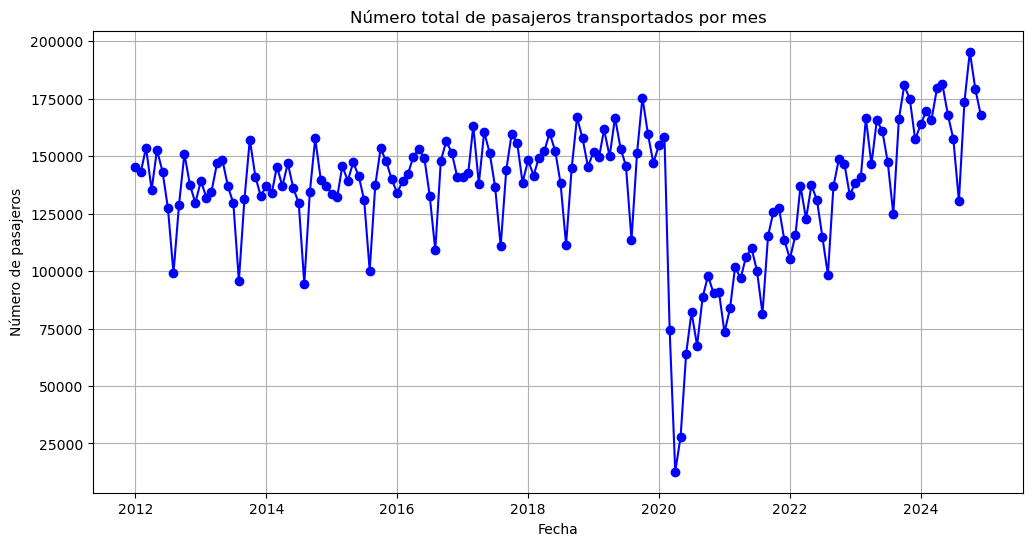

In [12]:
# ******************2. Representación gráfica y descomposición estacional
# Representación gráfica simple:
plt.figure(figsize=(12, 6))
plt.plot(df_cleaned['Total Nacional'], marker='o', linestyle='-', color='b')
plt.title("Número total de pasajeros transportados por mes")
plt.xlabel("Fecha")
plt.ylabel("Número de pasajeros")
plt.grid(True)
plt.show()


**-- Comentario o interpretación de la serie --**

Observamos que la serie presenta fluctuaciones mensuales bastante claras,
con picos y valles a lo largo del año (posible estacionalidad).

Alrededor de 2020 se aprecia un descenso muy pronunciado, en algunos meses se
registra el mínimo histórico de pasajeros y posteriormente una fuerte recuperación
que supera los niveles prepandemia en los últimos años (2023-2024).

En general, la tendencia a largo plazo parece ascendente después del rebote post 2020.

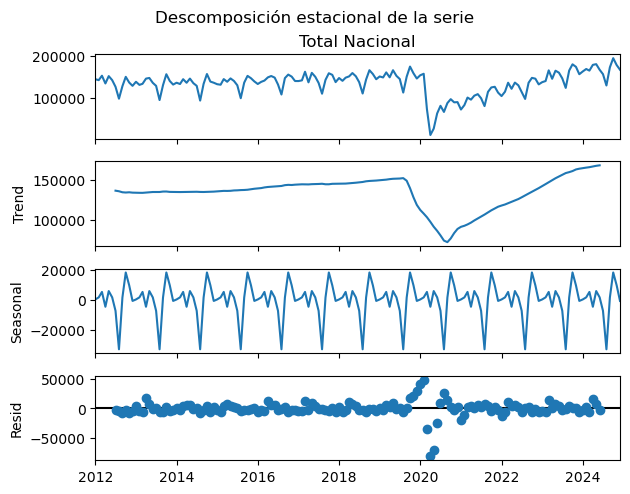

In [15]:
# Descomposición estacional
# period=12 asume estacionalidad anual si tus datos son mensuales.
result = sm.tsa.seasonal_decompose(df_cleaned['Total Nacional'], 
                                   model='additive', 
                                   period=12)
result.plot()
plt.suptitle("Descomposición estacional de la serie", y=1.02)
plt.show()


**Conclusión Descomposición**

*Serie original (observed)*

Se ve la evolución real de la serie mes a mes. Destaca un descenso muy acusado alrededor de 2020 (el efecto de la pandemia) y una posterior recuperación que supera incluso los valores previos a dicha caída.

*Tendencia (trend)*

En la segunda franja del gráfico se aprecia una tendencia aproximadamente estable o ligeramente creciente desde 2012 hasta 2019.
A partir de 2020 se observa un descenso muy fuerte (que coincide con la parte más dura de las restricciones y el desplome de pasajeros) y, posteriormente, una recuperación clara de la tendencia hasta niveles incluso superiores a los iniciales.

*Estacionalidad (seasonal)*

En la tercera franja se aprecia un patrón cíclico repetitivo con periodo 12 (un año), que indica que determinados meses tienden a tener valores por encima o por debajo de la tendencia.
La amplitud de esta estacionalidad (cuánto sube o baja en cada “cresta” o “valle” estacional) parece bastante marcada: la oscilación puede rondar ±10.000–15.000 pasajeros a lo largo del año (dependiendo del eje de tu gráfico).
Este componente estacional, en general, se ha mantenido con un perfil estable en el tiempo, aunque la magnitud del efecto relativo se vuelve más notable en los meses de 2020–2021 por la fuerte caída del total.

*Residuales (resid)*

Finalmente, en la parte inferior del gráfico se muestra lo que queda tras extraer tendencia y estacionalidad del dato original.
Se ven varios puntos especialmente destacados en 2020 (residuales muy negativos), lo que indica que la caída estuvo incluso por debajo de lo que un simple patrón de tendencia + estacionalidad podía anticipar.
A partir de 2021, los residuales vuelven a agruparse más cercanos a cero, aunque con ligeras fluctuaciones.

In [17]:
# Mostrar los primeros 12 valores de estacionalidad
print("\nEstacionalidad:")
print(result.seasonal.head(12))


Estacionalidad:
Fecha
2012-01-01      382.936053
2012-02-01     1779.856192
2012-03-01     5446.932581
2012-04-01    -4534.091725
2012-05-01     6026.147859
2012-06-01     1786.998553
2012-07-01    -7253.664641
2012-08-01   -33139.768808
2012-09-01     1698.567998
2012-10-01    18540.061053
2012-11-01     9877.522859
2012-12-01     -611.497975
Freq: MS, Name: seasonal, dtype: float64


**La estacionalidad** 

En esa tabla se muestran los valores de la componente estacional para cada uno de los 12 meses del año 2012. Cada valor indica, en promedio, cuánto se desvía (positivo o negativo) la serie respecto de su tendencia en ese mes en particular.

*Valores positivos* (p. ej., en marzo o mayo) significan que, en promedio, esos meses tienden a presentar más pasajeros de lo que marca la tendencia.

*Valores negativos* (como abril, julio o agosto, con mayor énfasis en agosto con -33139) indican que esos meses suelen presentar menos pasajeros en comparación con la tendencia “media” de la serie.



In [21]:
# ******************3. Separación en TRAIN y TEST
# Número de observaciones a reservar
n_test = 12
train = df_cleaned.iloc[:-n_test].copy()
test = df_cleaned.iloc[-n_test:].copy()
# ********4. Ajustar un modelo de suavizado exponencial (Holt-Winters)
train['Total Nacional'] = pd.to_numeric(train['Total Nacional'], errors='coerce')
test['Total Nacional'] = pd.to_numeric(test['Total Nacional'], errors='coerce')

print(f"Tamaño del entrenamiento: {train.shape[0]} observaciones")
print(f"Tamaño del test: {test.shape[0]} observaciones")

Tamaño del entrenamiento: 144 observaciones
Tamaño del test: 12 observaciones


In [23]:
# ********4. Ajustar un modelo de suavizado exponencial (Holt-Winters)
# Ajustamos el modelo en TRAIN
hw_model = ExponentialSmoothing(
    train['Total Nacional'],
    trend='add',            # 'add' para tendencia aditiva
    seasonal='add',         # 'add' si la estacionalidad es aditiva (pruébalo o revisa la gráfica)
    seasonal_periods=12     # frecuencia mensual
)
hw_fit = hw_model.fit()

In [25]:
# También puedes ver un resumen más detallado:
# (No todos los atributos están implementados como en ARIMA, pero verás info básica)
print("\n***** RESUMEN DEL MODELO *****")
print(hw_fit.summary())


***** RESUMEN DEL MODELO *****
                       ExponentialSmoothing Model Results                       
Dep. Variable:           Total Nacional   No. Observations:                  144
Model:             ExponentialSmoothing   SSE                    23683752034.867
Optimized:                         True   AIC                           2756.227
Trend:                         Additive   BIC                           2803.744
Seasonal:                      Additive   AICC                          2761.699
Seasonal Periods:                    12   Date:                 Thu, 20 Feb 2025
Box-Cox:                          False   Time:                         13:31:17
Box-Cox Coeff.:                    None                                         
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.9596429                alpha               

El modelo Holt-Winters aditivo con estos parámetros explica razonablemente la serie, aunque con la peculiaridad de una tendencia muy baja y un ajuste estacional que no cambia drásticamente de un año a otro.

Se observan que las predicciones tienden a subestimar o sobreestimar ciertos meses (especialmente tras 2020), podría valer la pena probar otras configuraciones (tendencia/estacionalidad multiplicativa o un modelo SARIMA) para ver si capturan mejor la dinámica reciente.

In [28]:
# Predicciones en TEST
hw_pred = hw_fit.forecast(steps=len(test))

# Comparo con los valores reales del TEST
comparison_hw = pd.DataFrame({
    'Real': test['Total Nacional'],
    'Predicción': hw_pred
})
comparison_hw

,Real,Predicción
2024-01-01,163859,159111.879815
2024-02-01,169720,158633.382758
2024-03-01,165912,163566.235338
2024-04-01,179568,159331.661649
2024-05-01,181225,172057.880746
2024-06-01,167892,164196.265007
2024-07-01,157422,151979.338456
2024-08-01,130540,121932.361209
2024-09-01,173713,154796.240594
2024-10-01,195483,174205.441930


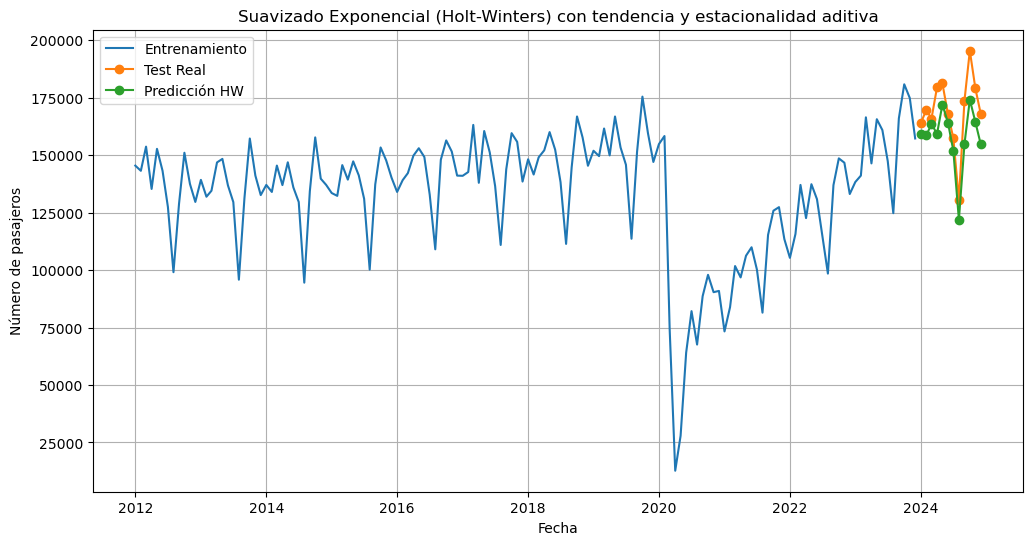

In [94]:
# Representación gráfica
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['Total Nacional'], label='Entrenamiento')
plt.plot(test.index, test['Total Nacional'], label='Test Real', marker='o')
plt.plot(test.index, hw_pred, label='Predicción HW', marker='o')
plt.title("Suavizado Exponencial (Holt-Winters) con tendencia y estacionalidad aditiva")
plt.xlabel("Fecha")
plt.ylabel("Número de pasajeros")
plt.legend()
plt.grid(True)
plt.show()


**A partir del gráfico comparativo entre el conjunto de entrenamiento (línea azul), el test real (puntos naranjas) y la predicción Holt-Winters (puntos verdes), se pueden extraer las siguientes observaciones:**

*Captura de la tendencia general*

El modelo Holt-Winters (HW) parece aprender la tendencia ascendente que se ve en la serie tras el “bache” de 2020, manteniéndose en un nivel medio que no se aleja demasiado de los datos reales en el test.
Sin embargo, hay meses donde la predicción queda algo por debajo del valor real (especialmente en los picos altos), indicando que quizá la serie se ha recuperado con más fuerza de lo que la tendencia aditiva capturó en el período de entrenamiento.

*Componente estacional*

El método HW con tendencia y estacionalidad “aditiva” logra reflejar, al menos de forma aproximada, los altibajos mensuales típicos de la serie.
No obstante, el gráfico sugiere que en ciertos meses la amplitud de la estacionalidad real en el período de test es un poco mayor que la pronosticada.

*Potencial subestimación / sobreestimación*

En el gráfico, en la mayoría de los puntos, las predicciones (verde) están cercanas al valor real (naranja), pero se aprecia una tendencia a subestimar algunos de los valores máximos y, en menor medida, a sobreestimar algunos meses más bajos.
Esto puede significar que el modelo Holt-Winters aditivo no está captando al 100% la dinámica post-2020, quizá porque los patrones de demanda cambiaron estructuralmente (o porque la recuperación está siendo algo más acelerada de lo que la estructura lineal de tendencia y estacionalidad puede modelar).

**CONCLUSION**

En términos globales, el modelo Holt-Winters aditivo sí reproduce razonablemente la evolución, se ve que las predicciones no están “completamente fuera” de la realidad.

Sin embargo, se percibe un ligero sesgo en varios puntos del horizonte de test, por lo que convendría chequear métricas de error para cuantificar esas desviaciones.

También podría explorarse una versión multiplicativa para la estacionalidad o la tendencia, o un modelo ARIMA/SARIMA que permita una dinámica diferente, para ver si se mejora la precisión de la predicción.

In [33]:
# HAGO UN BUCLE PARA ENCONTRAR EL MEJOR MODELO DE SUAVIZADO
# Definimos las opciones de tendencia y estacionalidad
trend_options = ['add', 'mul', None]
seasonal_options = ['add', 'mul', None]
seasonal_periods = 12  # Asumiendo periodicidad mensual anual

results = []

# Ajustamos y comparamos modelos
for trend, season in product(trend_options, seasonal_options):
    # Evitamos el caso en el que no haya ni tendencia ni estacionalidad
    if trend is None and season is None:
        continue
    
    try:
        # Ajustamos modelo
        model = ExponentialSmoothing(
            train['Total Nacional'],
            trend=trend,
            seasonal=season,
            seasonal_periods=seasonal_periods
        )
        fitted_model = model.fit(optimized=True)
        
        # Predicciones en el horizonte 'test'
        forecast = fitted_model.forecast(steps=len(test))
        
        # Calculamos métricas de error
        mae = mean_absolute_error(test['Total Nacional'], forecast)
        rmse = mean_squared_error(test['Total Nacional'], forecast, squared=False)
        aic = fitted_model.aic
        bic = fitted_model.bic
        
        # Guardamos resultados
        results.append({
            'trend': trend,
            'seasonal': season,
            'AIC': aic,
            'BIC': bic,
            'MAE': mae,
            'RMSE': rmse,
            'model': fitted_model
        })
    
    except Exception as e:
        # Algunos ajustes pueden fallar (por ejemplo si hay ceros en los datos y usas 'mul')
        print(f"Error con trend={trend}, seasonal={season}: {e}")

# Ordenamos la tabla de resultados para ver los mejores
results_df = pd.DataFrame(results)
results_df_sorted = results_df.sort_values(by='AIC', ascending=True)  # o por 'RMSE', etc.

print("Resultados ordenados por AIC (menor es mejor):")
print(results_df_sorted[['trend','seasonal','AIC','BIC','MAE','RMSE']].head())

# Mejor modelo según la métrica elegida (AIC)
best_row = results_df_sorted.iloc[0]  # la primera fila es la de menor AIC
best_model = best_row['model']
print(f"\nMejor modelo: Trend={best_row['trend']}, Seasonal={best_row['seasonal']}")
print(f"AIC={best_row['AIC']}, RMSE={best_row['RMSE']}")
print("\nResumen del mejor modelo:\n", best_model.summary())

Resultados ordenados por AIC (menor es mejor):
  trend seasonal          AIC          BIC           MAE          RMSE
7  None      mul  2743.186196  2784.763582   9570.154858  11640.022099
1   add      mul  2747.063346  2794.580358  10711.769218  12746.457473
6  None      add  2751.997067  2793.574453   9312.150799  11254.045790
3   mul      add  2755.928053  2803.445066  11028.977047  12697.634294
0   add      add  2756.226817  2803.743829  11115.082624  12784.951579

Mejor modelo: Trend=None, Seasonal=mul
AIC=2743.1861958093223, RMSE=11640.022099452432

Resumen del mejor modelo:
                        ExponentialSmoothing Model Results                       
Dep. Variable:           Total Nacional   No. Observations:                  144
Model:             ExponentialSmoothing   SSE                    22242550771.080
Optimized:                         True   AIC                           2743.186
Trend:                             None   BIC                           2784.764
Season

**Modelo Seleccionado**

El mejor por AIC es un Holt‐Winters sin componente de tendencia (trend=None) pero con estacionalidad multiplicativa (seasonal='mul').

Esto nos sugiere que los datos muestran un patrón estacional más acorde a un factor proporcional (como meses “fuertes” y “débiles” escalan en proporción a su nivel), mientras que no se detecta una tendencia lineal clara que el modelo quiera mantener de manera aditiva o multiplicativa.

**Parámetros Principales**

α≈0.95: Indica un fuerte peso dado a las observaciones más recientes a la hora de actualizar el “nivel” de la serie. El modelo reacciona rápidamente a cambios en el corto plazo.

γ≈0.25: Controla la actualización de la componente estacional. Un valor moderado como el que obtenemos nos muestra que el modelo va ajustando la forma estacional mes a mes, pero sin cambios bruscos.

Al no haber tendencia explícita (𝛽=0 en la práctica), la serie se mantiene en un “nivel” que va oscilando según el factor estacional multiplicativo.

**Estimadores de la estacionalidad**

Los initial_seasons.s0, s1, ..., s11 son factores estacionales multiplicativos para cada mes. Un valor cercano a 1 implica un mes parecido a la “media” (nivel 1), mientras que si fuera, por ejemplo, 1.2 implicaría +20% sobre el nivel, y 0.8 sería -20%.
Se ve que la mayoría están en torno a valores como 0.95, 1.04, 1.08, etc., reflejando que algunos meses multiplican o reducen el nivel básico de pasajeros.

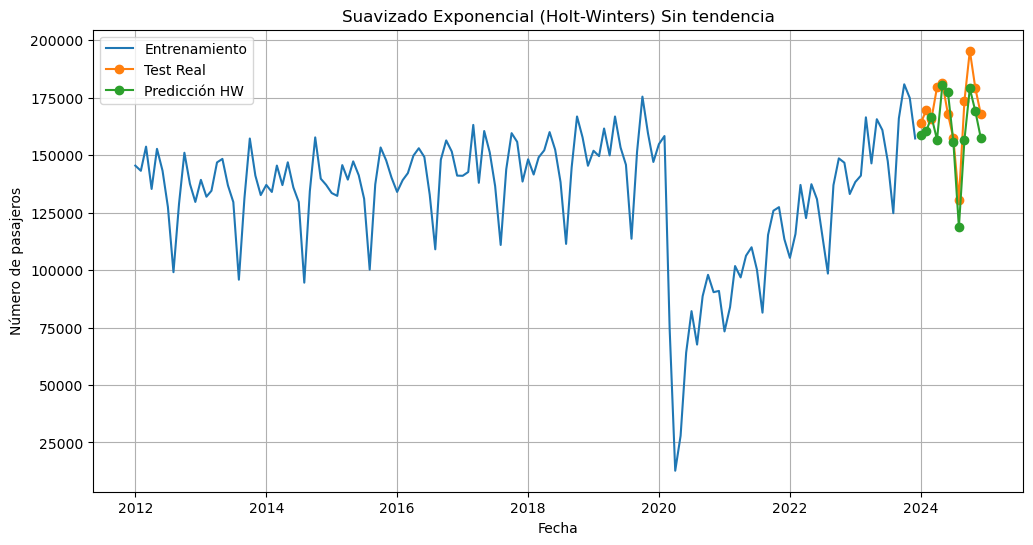

In [92]:
# Generar la predicción final y graficarla
best_forecast = best_model.forecast(steps=len(test))
# Representación gráfica
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['Total Nacional'], label='Entrenamiento')
plt.plot(test.index, test['Total Nacional'], label='Test Real', marker='o')
plt.plot(test.index, best_forecast, label='Predicción HW', marker='o')
plt.title("Suavizado Exponencial (Holt-Winters) Sin tendencia")
plt.xlabel("Fecha")
plt.ylabel("Número de pasajeros")
plt.legend()
plt.grid(True)
plt.show()



La estacionalidad multiplicativa (sin tendencia) parece capturar mejor la dinámica de la serie que las demás combinaciones, reflejando un patrón mensual proporcional.

El alto 𝛼 indica que el modelo se adapta deprisa a los cambios de corto plazo, mientras que 𝛾 moderado mantiene una estacionalidad estable.

Se ajusta bastante bien aunque con cierta desviación en algunos meses (picos altos y bajos). Esto se explica por lo inusual de la caída de 2020 y la posterior recuperación. Al no haber una tendencia explícita, el modelo hace un reajuste rápido del nivel (alto 𝛼) y aplica la estacionalidad multiplicativa, resultando un buen compromiso entre sobrerreacción y subestimación.

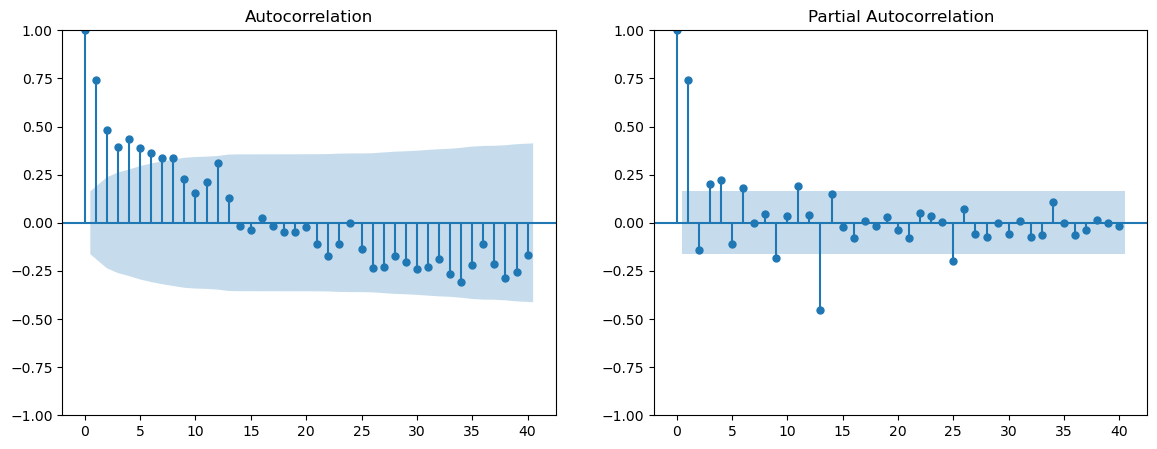

In [39]:
# *************** 5. Análisis de correlogramas y posible modelo ARIMA manual
# Visualizamos correlogramas en TRAIN
fig, ax = plt.subplots(1,2, figsize=(14,5))
plot_acf(train['Total Nacional'].dropna(), lags=40, ax=ax[0])
plot_pacf(train['Total Nacional'].dropna(), lags=40, ax=ax[1])
plt.show()

Tiene un pico importante en lag 1, lo que a menudo sugiere la presencia de un AR(1) al menos en la parte no estacional.
Hay otros picos moderados (positivos o negativos) en lags superiores (por ejemplo, en torno a lag 2 o 12–14) que podrían asociarse a componente AR o MA estacional (p. ej. un SAR(1) o SMA(1) en lag 12).

Los correlogramas invitan a ensayar un modelo ARIMA que incorpore estacionalidad (SARIMA) con diferencias regulares y/o estacionales y, posiblemente, un componente AR(1) (no estacional) y/o un MA estacional.

In [42]:
# Ejemplo SARIMA(1,1,1)(1,1,1,12)
mod_arima = sm.tsa.statespace.SARIMAX(train['Total Nacional'],
                                      order=(1,1,1),              # p,d,q
                                      seasonal_order=(1,1,1,12),  # P,D,Q,m
                                      enforce_stationarity=False,
                                      enforce_invertibility=False)
res_arima = mod_arima.fit()

print(res_arima.summary())


                                     SARIMAX Results                                      
Dep. Variable:                     Total Nacional   No. Observations:                  144
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -1292.978
Date:                            Thu, 20 Feb 2025   AIC                           2595.955
Time:                                    13:31:20   BIC                           2609.766
Sample:                                01-01-2012   HQIC                          2601.562
                                     - 12-01-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0398      0.853     -0.047      0.963      -1.711       1.631
ma.L1          0.2583      0.835   

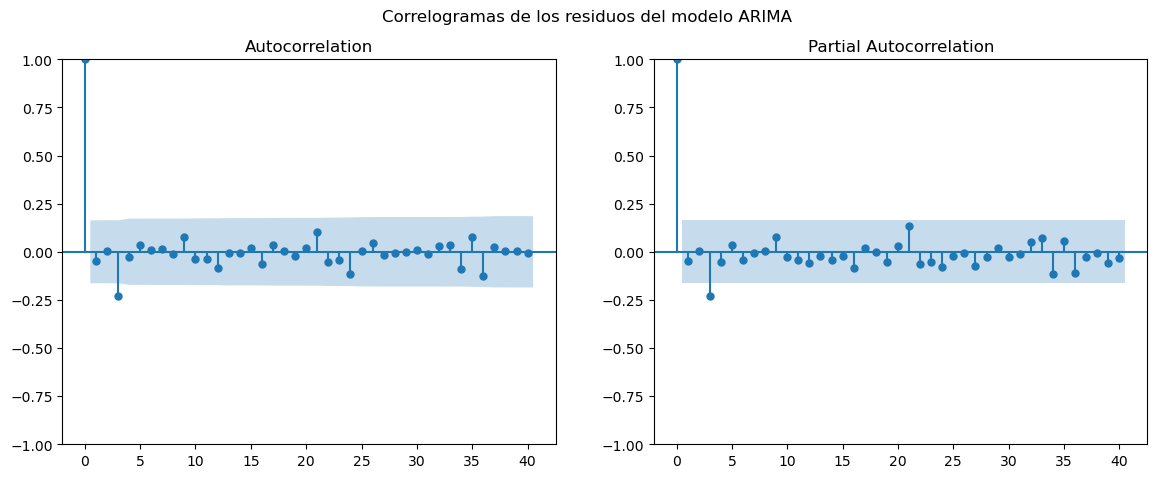

In [44]:
# Validación de la incorrelación de los residuos
residuals = res_arima.resid
fig, ax = plt.subplots(1,2, figsize=(14,5))
plot_acf(residuals.dropna(), lags=40, ax=ax[0])
plot_pacf(residuals.dropna(), lags=40, ax=ax[1])
plt.suptitle("Correlogramas de los residuos del modelo ARIMA")
plt.show()

A la vista de los correlogramas de los residuos (ACF y PACF) vemos ausencia de correlaciones significativas:

Ningún rezago de la ACF o la PACF sobresale de los intervalos de confianza, lo que indica que los residuos se comportan básicamente como “ruido blanco”.
Esto sugiere que el modelo (SARIMA(1,1,1)(1,1,1,12)) está capturando bien la dependencia temporal presente en los datos.

Es un modelo plausible, la falta de picos significativos en los residuales implica que no queda una estructura autocorrelacionada importante por modelar.
Por tanto, la especificación elegida (con diferencias regulares y estacionales, más componentes AR y MA en ambas escalas) es razonable para explicar la serie.

**Conclusión:**

Con los correlogramas de residuos “planos” y centrados en cero, podemos afirmar que el modelo ajustado pasa la prueba básica de estacionariedad en los errores y de ausencia de autocorrelación serial.

Eso valida el SARIMA(1,1,1)(1,1,1,12) como un buen candidato

In [47]:
mod_arima_forecast = res_arima.forecast(steps=len(test))
# Comparo con los valores reales del TEST
comparison_sarima = pd.DataFrame({
    'Real': test['Total Nacional'],
    'Predicción': mod_arima_forecast
})
comparison_sarima

,Real,Predicción
2024-01-01,163859,153967.027424
2024-02-01,169720,160066.306020
2024-03-01,165912,174474.895928
2024-04-01,179568,156275.755689
2024-05-01,181225,172031.900296
2024-06-01,167892,170487.016009
2024-07-01,157422,159148.124037
2024-08-01,130540,139197.590363
2024-09-01,173713,176738.439750
2024-10-01,195483,189955.083341


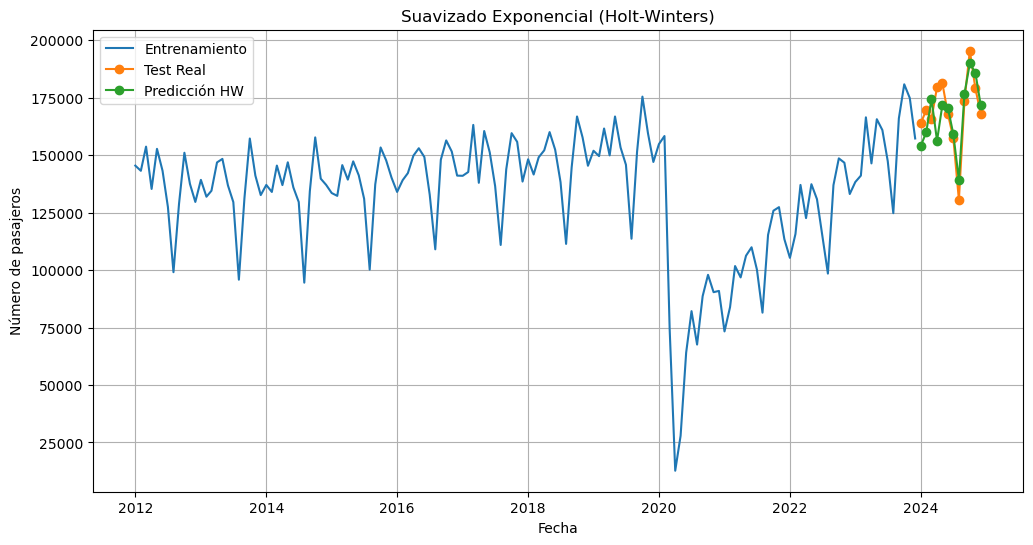

In [49]:
# Representación gráfica
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['Total Nacional'], label='Entrenamiento')
plt.plot(test.index, test['Total Nacional'], label='Test Real', marker='o')
plt.plot(test.index, mod_arima_forecast, label='Predicción HW', marker='o')
plt.title("Suavizado Exponencial (Holt-Winters)")
plt.xlabel("Fecha")
plt.ylabel("Número de pasajeros")
plt.legend()
plt.grid(True)
plt.show()

Se aprecia que el modelo sigue la tendencia general, pero en ciertos meses sobreestima o subestima la serie real. Esto es normal dada la fuerte disrupción en 2020 y la posterior recuperación irregular. Aun así, las predicciones se sitúan razonablemente cerca de los puntos de test, lo que sugiere que el modelo capta una parte significativa de la dinámica de la serie.

In [52]:
# ***********   6. Ajustar un modelo ARIMA con ajuste automático
auto_model = pm.auto_arima(
    train['Total Nacional'],
    start_p=0, max_p=3,    # rangos para p
    start_q=0, max_q=3,    # rangos para q
    d=None,                # dejar que lo estime
    seasonal=True, m=12,   # asumes estacionalidad mensual
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    D=None,
    trace=True,            # para ir viendo qué hace
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)
print(auto_model.summary())

# para comparar con tu conjunto de prueba.
auto_model.predict(n_periods=len(test))


Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=3349.042, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=3212.043, Time=0.09 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=3272.218, Time=0.04 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=3815.485, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=3236.847, Time=0.01 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=3213.914, Time=0.59 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=3211.154, Time=0.32 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=3212.522, Time=0.04 sec
 ARIMA(1,0,0)(2,0,1)[12] intercept   : AIC=inf, Time=0.95 sec
 ARIMA(1,0,0)(1,0,2)[12] intercept   : AIC=3207.026, Time=0.52 sec
 ARIMA(1,0,0)(0,0,2)[12] intercept   : AIC=3205.171, Time=0.11 sec
 ARIMA(0,0,0)(0,0,2)[12] intercept   : AIC=3337.349, Time=0.08 sec
 ARIMA(2,0,0)(0,0,2)[12] intercept   : AIC=3201.991, Time=0.16 sec
 ARIMA(2,0,0)(0,0,1)[12] intercept   : AIC=3210.645, Time=0.06 sec
 ARIMA(2,0,0)(1,0,2)[12]

2024-01-01    157427.862446
2024-02-01    156172.523275
2024-03-01    161343.959746
2024-04-01    147146.639812
2024-05-01    155206.818083
2024-06-01    151888.020536
2024-07-01    145931.937090
2024-08-01    135886.842496
2024-09-01    153271.440841
2024-10-01    159482.221753
2024-11-01    155421.887491
2024-12-01    148366.165458
Freq: MS, dtype: float64

In [58]:
# para comparar con tu conjunto de prueba.
autoarima_forecast = auto_model.predict(n_periods=len(test))

# Comparo con los valores reales del TEST
comparison_auto_arima = pd.DataFrame({
    'Real': test['Total Nacional'],
    'Predicción': autoarima_forecast
})
comparison_auto_arima

,Real,Predicción
2024-01-01,163859,157427.862446
2024-02-01,169720,156172.523275
2024-03-01,165912,161343.959746
2024-04-01,179568,147146.639812
2024-05-01,181225,155206.818083
2024-06-01,167892,151888.020536
2024-07-01,157422,145931.937090
2024-08-01,130540,135886.842496
2024-09-01,173713,153271.440841
2024-10-01,195483,159482.221753


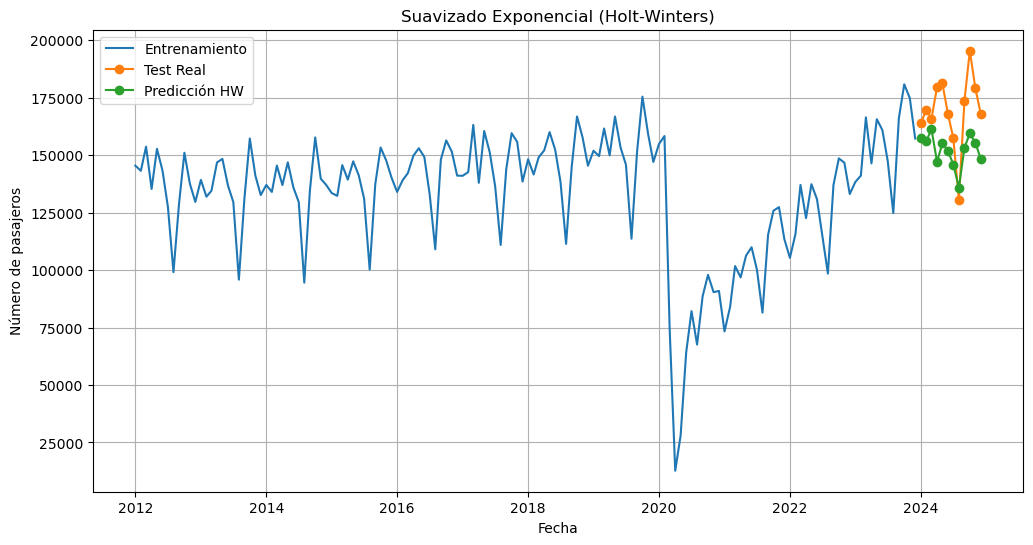

In [60]:
# Representación gráfica
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['Total Nacional'], label='Entrenamiento')
plt.plot(test.index, test['Total Nacional'], label='Test Real', marker='o')
plt.plot(test.index, autoarima_forecast, label='Predicción HW', marker='o')
plt.title("Suavizado Exponencial (Holt-Winters)")
plt.xlabel("Fecha")
plt.ylabel("Número de pasajeros")
plt.legend()
plt.grid(True)
plt.show()


A partir de estos resultados, se ve que el modelo ARIMA auto‐ajustado (con auto_arima) tiende a infrapredecir los valores en varios meses y presenta desviaciones mayores que las de otros modelos (por ejemplo, el mejor Holt‐Winters o el SARIMA manual). 

En concreto:

Los valores reales del test son regularmente más altos que la predicción automática.
Hay diferencias de hasta 20.000–30.000 pasajeros en algunos meses, lo que indica un ajuste menos fino a la estacionalidad y la recuperación post-2020.
Visualmente, la línea de predicción se queda “plana” respecto a los picos del test.

Por tanto, en este caso, el modelo escogido por auto_arima no captura tan bien la dinámica reciente de la serie ni su estacionalidad marcada, mostrando mayor error frente a los modelos alternativos que sí se adaptan mejor a la variación mensual real

**Mejor Modelo**

Dado lo observado los resultados comparativos, el modelo que mejor se ha comportado (menor AIC y mejor ajuste global) es Holt-Winters sin tendencia (trend=None) y con estacionalidad multiplicativa (seasonal="mul"). Ese modelo quedó reflejado con un valor de α cercano a 0.95 y γ alrededor de 0.25, y se ajusta mejor a la estacionalidad de la serie que las alternativas probadas (incluyendo el modelo ARIMA automático).

In [67]:
# ********  7. Expresión algebraica del modelo ajustado
# extraigo los parámetros estimados del summary()
best_model.summary()

Dep. Variable:,Total Nacional,No. Observations:,144
Model:,ExponentialSmoothing,SSE,22242550771.080
Optimized:,True,AIC,2743.186
Trend:,None,BIC,2784.764
Seasonal:,Multiplicative,AICC,2747.470
Seasonal Periods:,12,Date:,"Thu, 20 Feb 2025"
Box-Cox:,False,Time:,13:53:50
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.9478571,alpha,True
smoothing_seasonal,0.0521429,gamma,True



# Ecuaciones básicas del modelo Holt-Winters multiplicativo (sin tendencia)

Para cada periodo $(t)$, con estacionalidad de periodo $(m = 12)$:

1. **Actualización del nivel $(\ell_t)$**  
$$
\ell_t 
\;=\; 
0.9478571 \times \frac{y_t}{s_{t-m}}
\;+\;
\bigl(1 - 0.9478571\bigr)\,\ell_{t-1}.
$$

2. **Actualización de la estacionalidad $(s_t)$**  
$$
s_t 
\;=\; 
0.0521429 \times \frac{y_t}{\ell_t}
\;+\;
\bigl(1 - 0.0521429\bigr)\,s_{t-m}.
$$

3. **Pronóstico a $h$ pasos vista**  
$$
\widehat{y}_{t+h}
\;=\;
\ell_t
\times
s_{\,t - m + (h \bmod m)}.
$$

> Dado que `trend=None`, **no hay ecuación de tendencia** (i.e., $\beta=0$).

A diferencia de los modelos SARIMAX de statsmodels, la clase ExponentialSmoothing (Holt‐Winters) no provee directamente una función para obtener intervalos de confianza. Sin embargo, podemos aproximarlos suponiendo que los errores futuros siguen una distribución similar a la de los residuos del entrenamiento.

In [80]:
# Predicción para el período TEST
# Índice temporal para los 12 meses futuros
last_date = df_cleaned.index[-1]  # última fecha observada
future_dates = pd.date_range(start=last_date + pd.offsets.MonthBegin(1),
                             periods=12, freq='MS')

# Estimación de la desviación típica de los residuos (método aproximado)
residuals = best_model.fittedvalues - train['Total Nacional']
sigma = residuals.std()
z = 1.96  # ~ 95% de confianza

# Intervalos de confianza (IC) aproximados
lower_bound = best_forecast - z * sigma
upper_bound = best_forecast + z * sigma

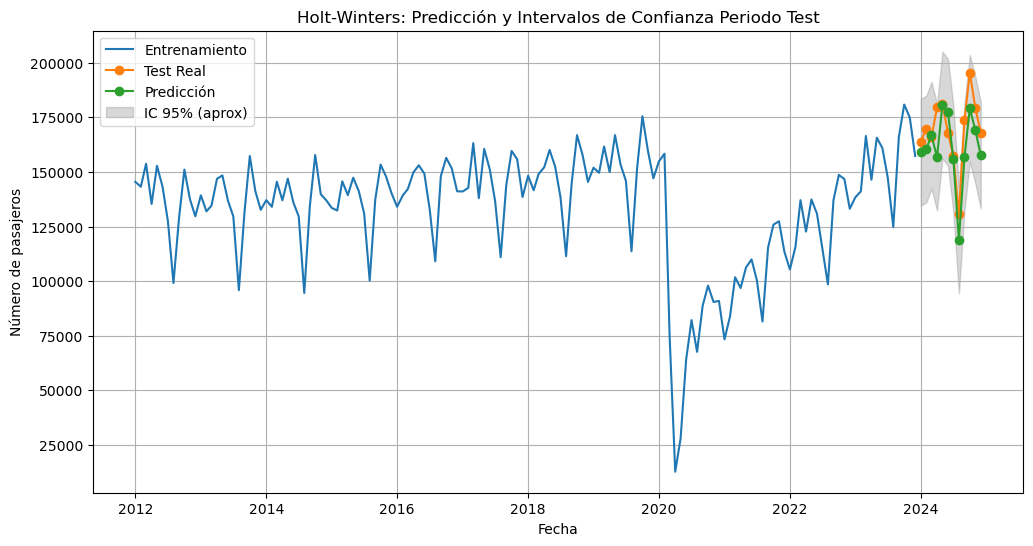

In [88]:
# Representación gráfica
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['Total Nacional'], label='Entrenamiento')
plt.plot(test.index, test['Total Nacional'], label='Test Real', marker='o')
plt.plot(test.index, best_forecast, label='Predicción', marker='o')
plt.fill_between(test.index, lower_bound, upper_bound,
                 color='gray', alpha=0.3, label='IC 95% (aprox)')
plt.title("Holt-Winters: Predicción y Intervalos de Confianza Periodo Test")
plt.xlabel("Fecha")
plt.ylabel("Número de pasajeros")
plt.legend()
plt.grid(True)
plt.show()

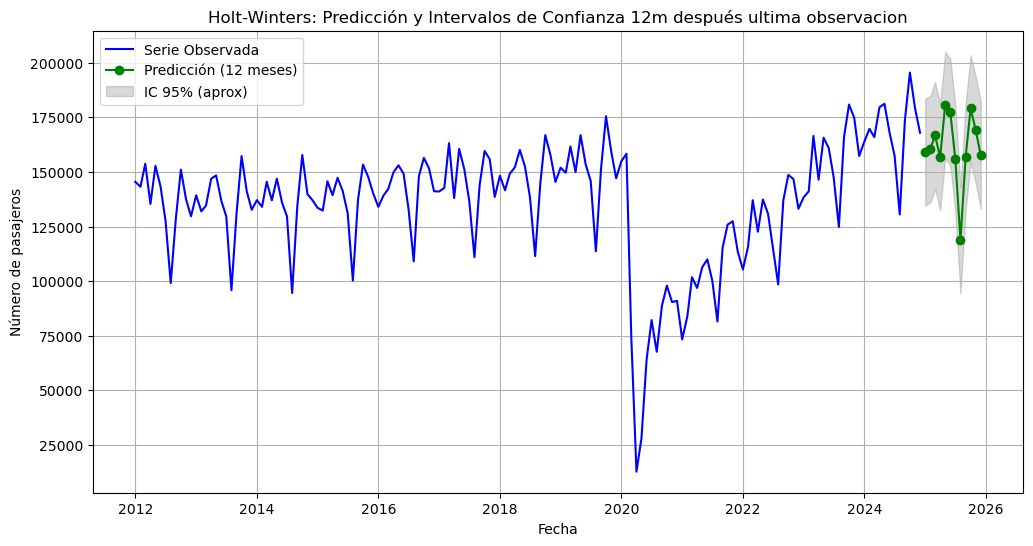

In [90]:
# Gráfico para los siguientes 12 meses a la fecha final de las observaciones
plt.figure(figsize=(12, 6))
plt.plot(df_cleaned.index, df_cleaned['Total Nacional'], label='Serie Observada', color='blue')
plt.plot(future_dates, best_forecast, label='Predicción (12 meses)', marker='o', color='green')
plt.fill_between(future_dates, lower_bound, upper_bound,
                 color='gray', alpha=0.3, label='IC 95% (aprox)')
plt.title("Holt-Winters: Predicción y Intervalos de Confianza 12m después ultima observacion")
plt.xlabel("Fecha")
plt.ylabel("Número de pasajeros")
plt.legend()
plt.grid(True)
plt.show()

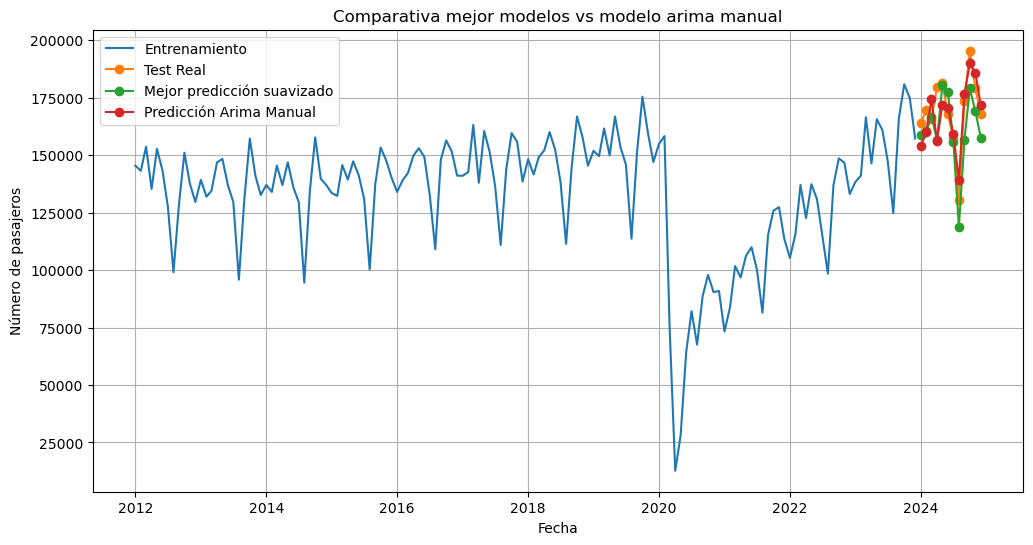

In [98]:
# ***********  9. Comparación de predicciones
# Representación gráfica
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['Total Nacional'], label='Entrenamiento')
plt.plot(test.index, test['Total Nacional'], label='Test Real', marker='o')
plt.plot(test.index, best_forecast, label='Mejor predicción suavizado', marker='o')
plt.plot(test.index, mod_arima_forecast, label='Predicción Arima Manual', marker='o')
plt.title("Comparativa mejor modelos vs modelo arima manual")
plt.xlabel("Fecha")
plt.ylabel("Número de pasajeros")
plt.legend()
plt.grid(True)
plt.show()

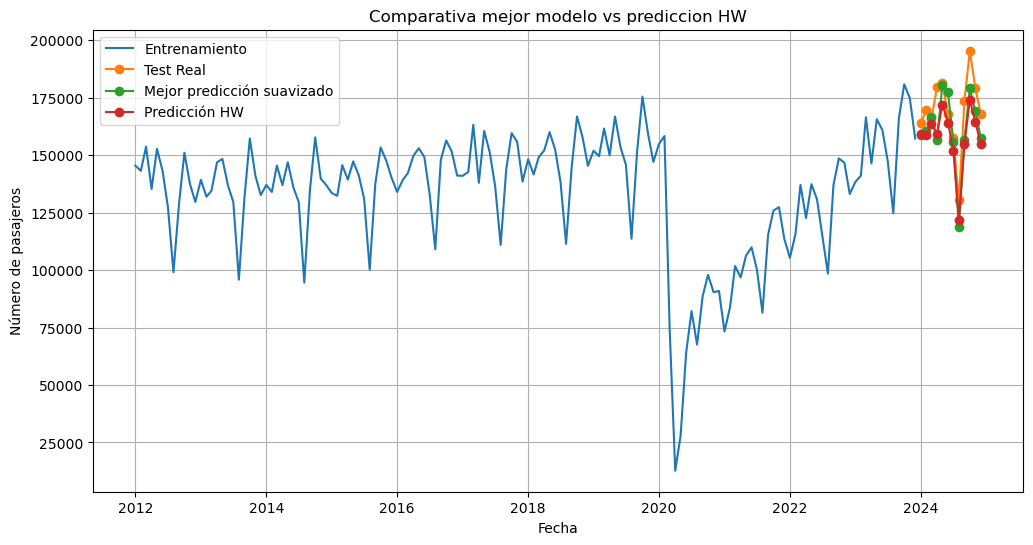

In [100]:
# Representación gráfica
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['Total Nacional'], label='Entrenamiento')
plt.plot(test.index, test['Total Nacional'], label='Test Real', marker='o')
plt.plot(test.index, best_forecast, label='Mejor predicción suavizado', marker='o')
plt.plot(test.index, hw_pred, label='Predicción HW', marker='o')
plt.title("Comparativa mejor modelo vs prediccion HW")
plt.xlabel("Fecha")
plt.ylabel("Número de pasajeros")
plt.legend()
plt.grid(True)
plt.show()

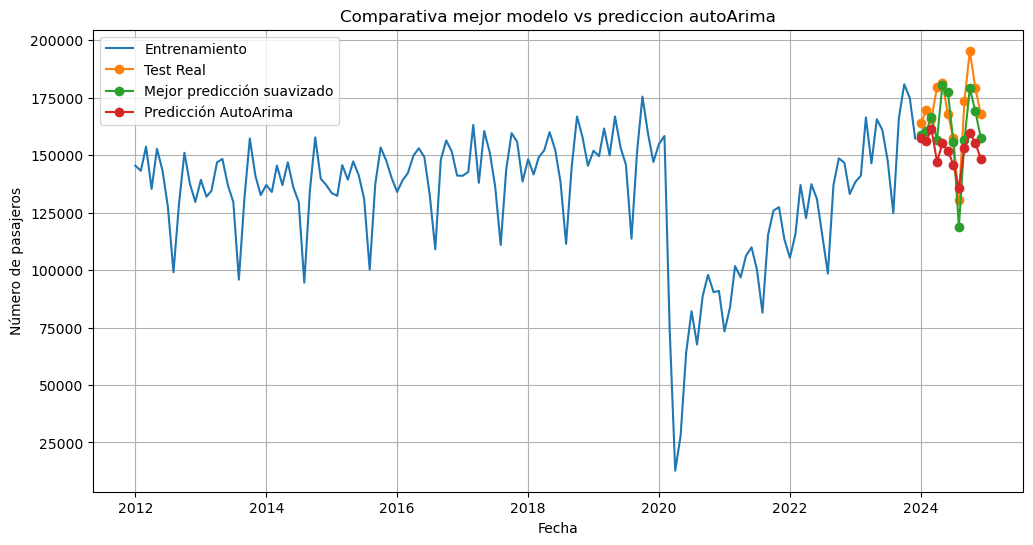

In [102]:
# Representación gráfica
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['Total Nacional'], label='Entrenamiento')
plt.plot(test.index, test['Total Nacional'], label='Test Real', marker='o')
plt.plot(test.index, best_forecast, label='Mejor predicción suavizado', marker='o')
plt.plot(test.index, autoarima_forecast, label='Predicción AutoArima', marker='o')
plt.title("Comparativa mejor modelo vs prediccion autoArima")
plt.xlabel("Fecha")
plt.ylabel("Número de pasajeros")
plt.legend()
plt.grid(True)
plt.show()

# Conclusiones

A lo largo del proceso de modelado, se han seguido estos pasos principales:

1. **Lectura y limpieza de datos**  
   - Se tomó la serie de pasajeros mensuales y se normalizó el formato de fechas, convirtiéndolas en un índice temporal. También se manejaron valores no numéricos y se estableció la frecuencia mensual.

2. **Análisis exploratorio y descomposición**  
   - La representación gráfica inicial y la descomposición estacional (aditiva) pusieron de manifiesto una **estacionalidad muy marcada** y la fuerte disrupción de 2020 (por la pandemia). Se observó una clara recuperación posterior, superando incluso los niveles previos.

3. **División en Train/Test**  
   - Se reservaron las últimas 12 observaciones para validación (*test*) y se trabajó con el resto para ajustar y comparar modelos.

4. **Modelos de Suavizado Exponencial (Holt–Winters)**  
   - Se probaron distintas configuraciones (trend y seasonal “add”, “mul” o `None`), seleccionando el mejor según el **AIC** y las métricas de error (MAE, RMSE) en el *test*.  
   - El **modelo ganador** resultó ser **Holt–Winters multiplicativo sin tendencia**, lo que refleja que la serie evoluciona con un nivel que se actualiza rápidamente (\(\alpha\) alto) y una estacionalidad proporcional (\(\gamma\) moderado).

5. **Modelos ARIMA/SARIMA**  
   - Se realizó un ajuste manual (SARIMA(1,1,1)(1,1,1,12) como hipótesis) y otro automático con `pmdarima.auto_arima`.  
   - Aunque algunos modelos ARIMA capturaron la tendencia básica y parte de la estacionalidad, en términos de métricas de error y comparación visual de las predicciones en el periodo *test*, **no superaron** al mejor Holt–Winters.

6. **Comparación final**  
   - Se superpusieron las distintas predicciones (Holt–Winters, ARIMA manual, Auto-ARIMA) sobre los datos reales de *test*.  
   - El **Holt–Winters multiplicativo sin tendencia** ofreció **predicciones más cercanas** a los valores reales, con menor error y AIC más bajo.

7. **Conclusión**  
   - El **modelo Holt–Winters multiplicativo (sin tendencia)** es el que **mejor** se ajusta a la dinámica de la serie, pues logra capturar la fuerte estacionalidad y adaptarse rápidamente a los cambios (alto \(\alpha\)).  
   - Las otras variantes de Holt–Winters y los modelos ARIMA no igualaron su desempeño, especialmente para el periodo de validación *test*.  
   - Por ello, se seleccionó como **modelo final**, destacando su capacidad para reproducir el patrón estacional post-2020 y ofrecer pronósticos más cercanos a la realidad.  

En conjunto, el análisis confirma que la estacionalidad juega un papel dominante en la serie y que, tras el impacto atípico de 2020, el método Holt–Winters multiplicativo reacciona de forma adecuada a la recuperación y mantiene un ajuste estable frente a las fluctuaciones mensuales.las fluctuaciones mensuales.